## Custom Middleware node style

In [1]:
import urllib.error
import urllib.request
import pprint
from langchain.tools import tool

from langchain.chat_models import init_chat_model

import langchain_groq
import os

from dotenv import load_dotenv

load_dotenv()


True

In [2]:
model_free = init_chat_model("llama-3.3-70b-versatile",
                        api_key=os.environ["GROQ_API_KEY"],
                        model_provider="groq",
                        # base_url="https://api.groq.com/openai/v1",
                        max_tokens=10000, temperature=0.0)

model_basic = init_chat_model("openrouter/free",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=1000, temperature=0.0)

model_medium = init_chat_model("openai/gpt-5.6-luna",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)

model_advanced = init_chat_model("openai/gpt-5.6-luna-pro",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)



In [3]:

# --- Core LangChain ---
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent, AgentState
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver

# --- Middleware building blocks -- every one used in this notebook ---
from langchain.agents.middleware import (
    AgentMiddleware,
    before_model,
    after_model,
    before_agent,
    after_agent,
    wrap_model_call,
    wrap_tool_call,
    hook_config,
    ModelRequest,
    ModelResponse,
)
from typing import Any, Callable
from typing_extensions import NotRequired
from langgraph.runtime import Runtime

`HumanInTheLoopMiddleware` handles approval for any tool. PIIMiddleware handles any of five PII types. CineBot's actual business, though, has rules nothing built-in could know in advance: "no customer books more than 2 movies in one session," "flag it if the bot ever mentions a rival cinema chain by name," "log every cancellation in our own specific audit format." Nothing generic can anticipate rules that are yours alone.

In [4]:
@tool
def check_showtimes(movie_title: str) -> str:
    """Check available showtimes for a movie at the cinema."""
    fake_showtimes = {
        "interstellar": "7:00 PM and 10:15 PM",
        "dunes part two": "9:30 PM only",
        "oppenheimer": "Sold out for tonight",
    }
    return fake_showtimes.get(movie_title.lower(), "No showtimes found for that title.")

@tool
def book_seats(movie_title: str, seat_count: int) -> str:
    """Book seats for a movie. Irreversible once confirmed."""
    return f"Booked {seat_count} seat(s) for {movie_title}."

@tool
def cancel_booking(booking_id: str) -> str:
    """Cancel an existing booking. Irreversible."""
    return f"Booking {booking_id} cancelled."

@tool
def get_refund_policy() -> str:
    """Get the cinema's refund policy -- exact wording, not to be paraphrased."""
    return "Refunds available up to 2 hours before showtime. No refunds after that."

cinebot_tools = [check_showtimes, book_seats, cancel_booking, get_refund_policy]

# Callbaks, Hooks, Middleware

Hooks are extension points in custom middleware that let you intercept, inspect, or modify agent execution at specific stages of the lifecycle.

In [5]:
@before_model
def log_before_model(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model."""
    print(f"[LOG] About to call model with {len(state['messages'])} messages so far")
    return None  # None means "observed, nothing to change"


In [6]:
@before_agent
def connecting_to_DB(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model."""
    print(f"I have connected to DB")
    return None  # None means "observed, nothing to change"

In [7]:
@after_agent
def disconnecting_to_DB(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model."""
    print(f"I have disconnected to DB")
    return None  # None means "observed, nothing to change"

In [23]:
from langchain.agents.middleware import before_model, after_model, AgentState
from langchain.messages import AIMessage
from langgraph.runtime import Runtime
from typing import Any


@before_model(can_jump_to=["end"])
def check_message_limit(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    if len(state["messages"]) >= 1:
        return {
            "messages": [AIMessage("Conversation limit reached.")],
            "jump_to": "end"
        }
    return None

@after_model
def log_after_model(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print(f"Model returned: {state['messages'][-1].content}")
    return None

In [24]:
logged_agent = create_agent(
    model=model_free, 
    tools=[], 
    middleware=[log_before_model,connecting_to_DB,disconnecting_to_DB,log_after_model,check_message_limit],
    checkpointer=InMemorySaver(),
    )


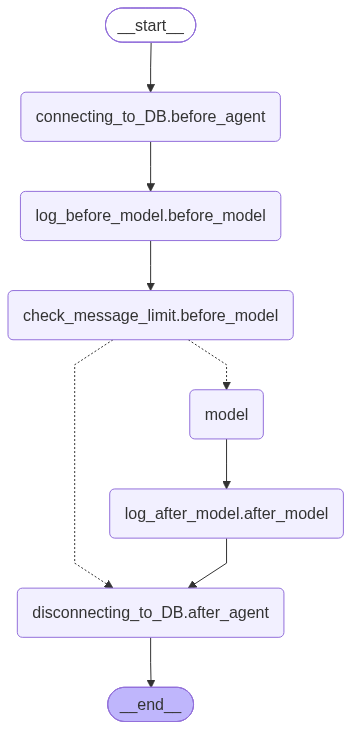

In [25]:
logged_agent

In [26]:
config = {"configurable": {"thread_id": "message-limit-demo"}}

In [27]:
result = logged_agent.invoke({"messages": [("user", "Hi, How are you?")]}, 
                             config=config,)

I have connected to DB
[LOG] About to call model with 1 messages so far
I have disconnected to DB


In [28]:
from rich import print as rprint

In [29]:
rprint(result)

{
    'messages': [
        HumanMessage(
            content='Hi, How are you?',
            additional_kwargs={},
            response_metadata={},
            id='de83928e-c32d-468a-974a-40d750f087c2'
        ),
        AIMessage(
            content='Conversation limit reached.',
            additional_kwargs={},
            response_metadata={},
            id='064ea47e-01f4-46ef-80cf-af6e3c3b39f6',
            tool_calls=[],
            invalid_tool_calls=[]
        )
    ]
}

In [30]:
result = logged_agent.invoke({"messages": [("user", "Great")]}, config=config)

I have connected to DB
[LOG] About to call model with 3 messages so far
I have disconnected to DB


In [31]:
rprint(result)

{
    'messages': [
        HumanMessage(
            content='Hi, How are you?',
            additional_kwargs={},
            response_metadata={},
            id='de83928e-c32d-468a-974a-40d750f087c2'
        ),
        AIMessage(
            content='Conversation limit reached.',
            additional_kwargs={},
            response_metadata={},
            id='064ea47e-01f4-46ef-80cf-af6e3c3b39f6',
            tool_calls=[],
            invalid_tool_calls=[]
        ),
        HumanMessage(
            content='Great',
            additional_kwargs={},
            response_metadata={},
            id='917b85ac-a965-46b1-ad56-85ef7f4f22aa'
        ),
        AIMessage(
            content='Conversation limit reached.',
            additional_kwargs={},
            response_metadata={},
            id='1813311c-673d-4a29-9d6d-63800c009da9',
            tool_calls=[],
            invalid_tool_calls=[]
        )
    ]
}

In [32]:
for i in range(3):
  result = logged_agent.invoke({"messages": [("user", f"Please cancel my Booking with ID B{100+i} ? ")]}, config=config)
  print(result)

I have connected to DB
[LOG] About to call model with 5 messages so far
I have disconnected to DB
{'messages': [HumanMessage(content='Hi, How are you?', additional_kwargs={}, response_metadata={}, id='de83928e-c32d-468a-974a-40d750f087c2'), AIMessage(content='Conversation limit reached.', additional_kwargs={}, response_metadata={}, id='064ea47e-01f4-46ef-80cf-af6e3c3b39f6', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Great', additional_kwargs={}, response_metadata={}, id='917b85ac-a965-46b1-ad56-85ef7f4f22aa'), AIMessage(content='Conversation limit reached.', additional_kwargs={}, response_metadata={}, id='1813311c-673d-4a29-9d6d-63800c009da9', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Please cancel my Booking with ID B100 ? ', additional_kwargs={}, response_metadata={}, id='e52ee04e-7546-471a-8c3d-f0b0ee62c317'), AIMessage(content='Conversation limit reached.', additional_kwargs={}, response_metadata={}, id='abb35331-6a76-46a1-bf93-09713ba73679', to

In [33]:
logged_agent = create_agent(
    model=model_free,
    tools=[book_seats, cancel_booking],
    middleware=[log_before_model, check_message_limit],
)

In [35]:
for i in range(3):
  result = logged_agent.invoke({"messages": [("user", f"Please cancel my Booking with ID B{100+i} ? ")]}, config=config)
  print(result)

[LOG] About to call model with 1 messages so far
{'messages': [HumanMessage(content='Please cancel my Booking with ID B100 ? ', additional_kwargs={}, response_metadata={}, id='d4c160e9-be7f-4ae3-ae35-c65a82f8dd6c'), AIMessage(content='Conversation limit reached.', additional_kwargs={}, response_metadata={}, id='1a346c04-804c-4b52-8e90-8160465b73f4', tool_calls=[], invalid_tool_calls=[])]}
[LOG] About to call model with 1 messages so far
{'messages': [HumanMessage(content='Please cancel my Booking with ID B101 ? ', additional_kwargs={}, response_metadata={}, id='34af7ddf-ed51-4580-a86a-f89ed2fa01d5'), AIMessage(content='Conversation limit reached.', additional_kwargs={}, response_metadata={}, id='0dd4e660-d977-4418-ae99-88ee97f9a481', tool_calls=[], invalid_tool_calls=[])]}
[LOG] About to call model with 1 messages so far
{'messages': [HumanMessage(content='Please cancel my Booking with ID B102 ? ', additional_kwargs={}, response_metadata={}, id='85d31a24-3ff7-4f18-b681-5d91ae7cd086'), 

In [36]:
result

{'messages': [HumanMessage(content='Please cancel my Booking with ID B102 ? ', additional_kwargs={}, response_metadata={}, id='85d31a24-3ff7-4f18-b681-5d91ae7cd086'),
  AIMessage(content='Conversation limit reached.', additional_kwargs={}, response_metadata={}, id='4df9f276-a353-4cd4-828b-ab7fe8303adc', tool_calls=[], invalid_tool_calls=[])]}